In [ ]:
# Cell 1 - Imports and load metric files

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

metric_files = {
    "XGBoost Model 1": CLEAN_DIR / "gdp_xgboost_model_1_metrics.csv",
    "XGBoost Model 2": CLEAN_DIR / "gdp_xgboost_model_2_metrics.csv",
    "XGBoost Model 3": CLEAN_DIR / "gdp_xgboost_model_3_metrics.csv",
    "Random Forest Model 1": CLEAN_DIR / "gdp_random_forest_model_1_metrics.csv",
    "Random Forest Model 2": CLEAN_DIR / "gdp_random_forest_model_2_metrics.csv",
    "Random Forest Model 3": CLEAN_DIR / "gdp_random_forest_model_3_metrics.csv",
}

for label, path in metric_files.items():
    print(label, "->", path.exists(), "|", path.name)

XGBoost Model 1 -> True | gdp_xgboost_model_1_metrics.csv
XGBoost Model 2 -> True | gdp_xgboost_model_2_metrics.csv
XGBoost Model 3 -> True | gdp_xgboost_model_3_metrics.csv
Random Forest Model 1 -> True | gdp_random_forest_model_1_metrics.csv
Random Forest Model 2 -> True | gdp_random_forest_model_2_metrics.csv
Random Forest Model 3 -> True | gdp_random_forest_model_3_metrics.csv


In [2]:
# Cell 2 - Combine test level metrics

metric_frames = []

for label, path in metric_files.items():
    if not path.exists():
        print("Missing:", path.name)
        continue

    df = pd.read_csv(path).copy()
    df["compare_model_label"] = label
    metric_frames.append(df)

all_metrics_df = pd.concat(metric_frames, ignore_index=True)

test_level_metrics_df = (
    all_metrics_df[
        (all_metrics_df["split"] == "test") &
        (all_metrics_df["scale"] == "level_gdp_usd")
    ]
    [
        [
            "compare_model_label",
            "n_obs",
            "MAE",
            "RMSE",
            "MAPE_pct",
            "R_squared"
        ]
    ]
    .copy()
)

display(test_level_metrics_df.sort_values(["compare_model_label"]))

,compare_model_label,n_obs,MAE,RMSE,MAPE_pct,R_squared
14,Random Forest Model 1,1042,"1,942.1681","5,420.2787",10.0114,0.9668
18,Random Forest Model 2,813,"1,687.2767","4,027.7543",9.8957,0.9685
22,Random Forest Model 3,813,"1,652.5858","3,959.3218",9.4829,0.9696
2,XGBoost Model 1,1042,"2,088.0187","5,968.9899",10.2253,0.9598
6,XGBoost Model 2,813,"1,858.3526","4,168.2013",12.3253,0.9663
10,XGBoost Model 3,813,"1,716.3037","4,110.5737",9.9803,0.9672


In [3]:
# Cell 3 - Add family and model group labels

def parse_family(label):
    return "XGBoost" if "XGBoost" in label else "Random Forest"

def parse_model_group(label):
    if "Model 1" in label:
        return "Model 1"
    if "Model 2" in label:
        return "Model 2"
    if "Model 3" in label:
        return "Model 3"
    return "Unknown"

test_level_metrics_df["family"] = test_level_metrics_df["compare_model_label"].apply(parse_family)
test_level_metrics_df["model_group"] = test_level_metrics_df["compare_model_label"].apply(parse_model_group)

display(test_level_metrics_df.sort_values(["model_group", "family"]))

,compare_model_label,n_obs,MAE,RMSE,MAPE_pct,R_squared,family,model_group
14,Random Forest Model 1,1042,"1,942.1681","5,420.2787",10.0114,0.9668,Random Forest,Model 1
2,XGBoost Model 1,1042,"2,088.0187","5,968.9899",10.2253,0.9598,XGBoost,Model 1
18,Random Forest Model 2,813,"1,687.2767","4,027.7543",9.8957,0.9685,Random Forest,Model 2
6,XGBoost Model 2,813,"1,858.3526","4,168.2013",12.3253,0.9663,XGBoost,Model 2
22,Random Forest Model 3,813,"1,652.5858","3,959.3218",9.4829,0.9696,Random Forest,Model 3
10,XGBoost Model 3,813,"1,716.3037","4,110.5737",9.9803,0.9672,XGBoost,Model 3


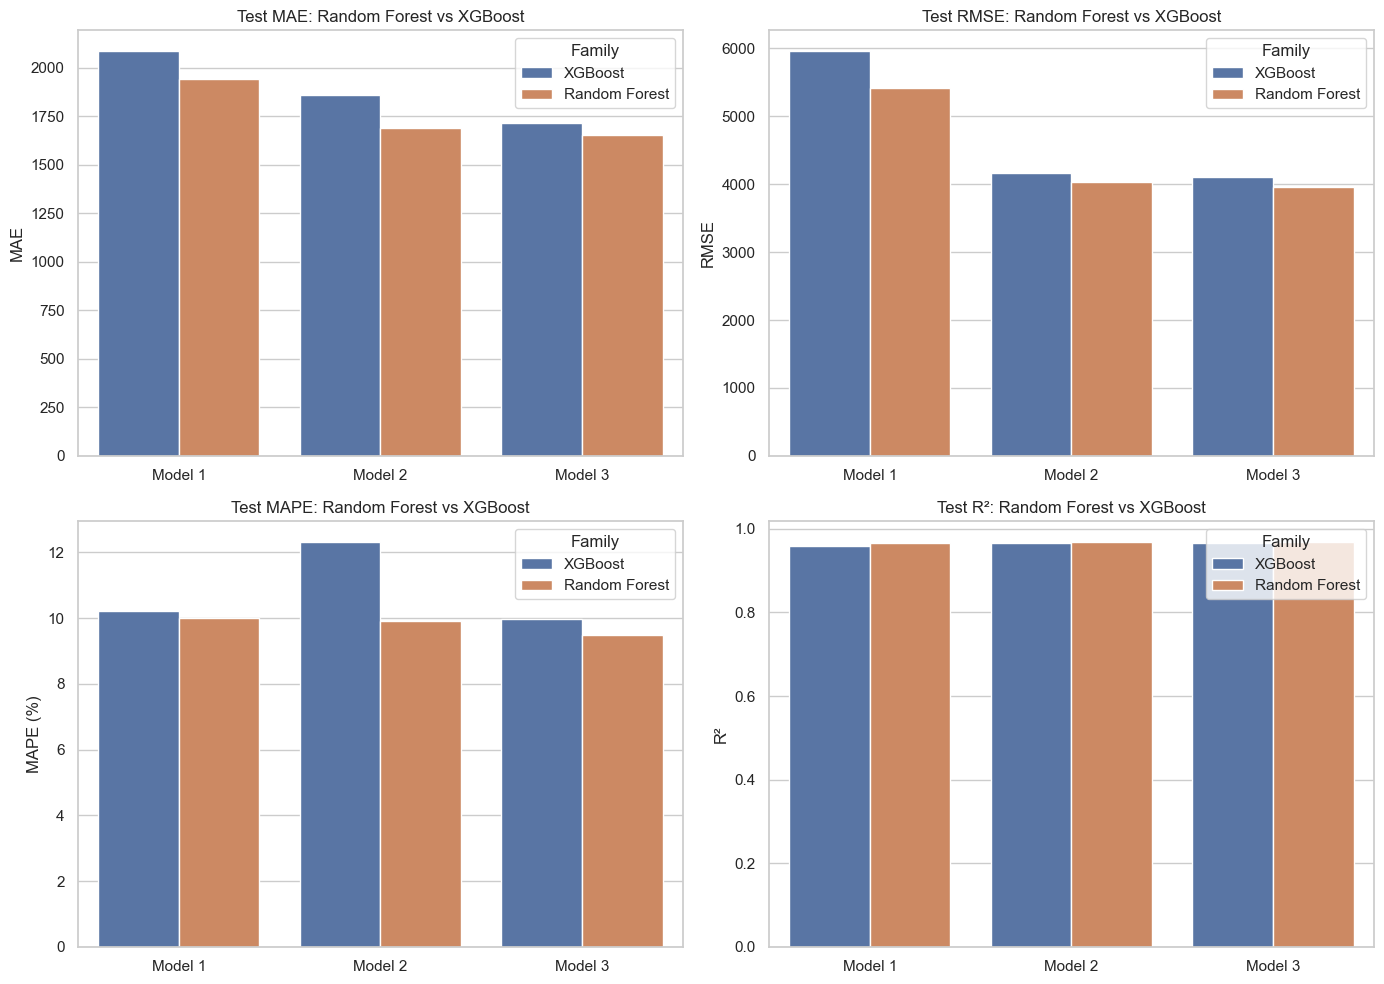

In [4]:
# Cell 4 - Bar charts: Random Forest vs XGBoost by model group

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=test_level_metrics_df,
    x="model_group",
    y="MAE",
    hue="family",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Test MAE: Random Forest vs XGBoost")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MAE")

sns.barplot(
    data=test_level_metrics_df,
    x="model_group",
    y="RMSE",
    hue="family",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Test RMSE: Random Forest vs XGBoost")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("RMSE")

sns.barplot(
    data=test_level_metrics_df,
    x="model_group",
    y="MAPE_pct",
    hue="family",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Test MAPE: Random Forest vs XGBoost")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("MAPE (%)")

sns.barplot(
    data=test_level_metrics_df,
    x="model_group",
    y="R_squared",
    hue="family",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Test R²: Random Forest vs XGBoost")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("R²")

for ax in axes.flat:
    ax.legend(title="Family")

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 - Load all test prediction files

prediction_files = {
    "xgb_m1": CLEAN_DIR / "gdp_xgboost_model_1_test_predictions.csv",
    "xgb_m2": CLEAN_DIR / "gdp_xgboost_model_2_test_predictions.csv",
    "xgb_m3": CLEAN_DIR / "gdp_xgboost_model_3_test_predictions.csv",
    "rf_m1": CLEAN_DIR / "gdp_random_forest_model_1_test_predictions.csv",
    "rf_m2": CLEAN_DIR / "gdp_random_forest_model_2_test_predictions.csv",
    "rf_m3": CLEAN_DIR / "gdp_random_forest_model_3_test_predictions.csv",
}

pred_dfs = {key: pd.read_csv(path) for key, path in prediction_files.items()}
print("Loaded prediction files.")

Loaded prediction files.


In [6]:
# Cell 6 - Helper to compare RF vs XGB for one model group

def build_family_compare_yearly(df_a, df_b, label_a, label_b):
    join_cols = ["country_code", "feature_year", "target_year"]

    a = df_a[
        join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]
    ].copy().rename(columns={"predicted_gdp_next_year": "pred_a"})

    b = df_b[
        join_cols + ["predicted_gdp_next_year"]
    ].copy().rename(columns={"predicted_gdp_next_year": "pred_b"})

    merged = a.merge(b, on=join_cols, how="inner")

    yearly = (
        merged.groupby("target_year", as_index=False)
        .agg(
            n_obs=("actual_gdp_next_year", "size"),
            actual_gdp=("actual_gdp_next_year", "mean"),
            pred_a=("pred_a", "mean"),
            pred_b=("pred_b", "mean")
        )
        .sort_values("target_year")
        .reset_index(drop=True)
    )

    yearly["label_a"] = label_a
    yearly["label_b"] = label_b
    return yearly

In [7]:
# Cell 7 - Build yearly comparison tables

model_1_family_compare = build_family_compare_yearly(
    pred_dfs["xgb_m1"], pred_dfs["rf_m1"],
    "XGBoost Model 1", "Random Forest Model 1"
)

model_2_family_compare = build_family_compare_yearly(
    pred_dfs["xgb_m2"], pred_dfs["rf_m2"],
    "XGBoost Model 2", "Random Forest Model 2"
)

model_3_family_compare = build_family_compare_yearly(
    pred_dfs["xgb_m3"], pred_dfs["rf_m3"],
    "XGBoost Model 3", "Random Forest Model 3"
)

display(model_1_family_compare)
display(model_2_family_compare)
display(model_3_family_compare)

,target_year,n_obs,actual_gdp,pred_a,pred_b,label_a,label_b
0,2019,210,"19,075.1284","19,617.1834","19,556.1861",XGBoost Model 1,Random Forest Model 1
1,2020,211,"17,672.2624","19,645.5262","19,628.0738",XGBoost Model 1,Random Forest Model 1
2,2021,209,"20,423.8917","17,964.8381","18,112.4817",XGBoost Model 1,Random Forest Model 1
3,2022,209,"21,142.7474","20,069.9142","20,055.9330",XGBoost Model 1,Random Forest Model 1
4,2023,203,"21,902.4676","20,628.4520","20,475.1383",XGBoost Model 1,Random Forest Model 1


,target_year,n_obs,actual_gdp,pred_a,pred_b,label_a,label_b
0,2019,166,"15,698.9605","16,766.1360","16,293.8758",XGBoost Model 2,Random Forest Model 2
1,2020,166,"14,549.3612","16,552.4605","16,152.4993",XGBoost Model 2,Random Forest Model 2
2,2021,162,"17,155.0981","15,422.7333","15,080.4178",XGBoost Model 2,Random Forest Model 2
3,2022,160,"18,048.6179","17,538.5251","17,062.4061",XGBoost Model 2,Random Forest Model 2
4,2023,159,"18,914.0876","18,263.2532","17,719.6101",XGBoost Model 2,Random Forest Model 2


,target_year,n_obs,actual_gdp,pred_a,pred_b,label_a,label_b
0,2019,166,"15,698.9605","16,375.2727","16,232.8993",XGBoost Model 3,Random Forest Model 3
1,2020,166,"14,549.3612","16,159.8303","16,113.4938",XGBoost Model 3,Random Forest Model 3
2,2021,162,"17,155.0981","15,154.9540","15,039.9489",XGBoost Model 3,Random Forest Model 3
3,2022,160,"18,048.6179","17,298.4945","17,070.2421",XGBoost Model 3,Random Forest Model 3
4,2023,159,"18,914.0876","17,848.6621","17,775.7104",XGBoost Model 3,Random Forest Model 3


In [8]:
# Cell 8 - Plot helper

def plot_family_compare(yearly_df, title, color_a="#e15759", color_b="#59a14f"):
    plt.figure(figsize=(12, 6))

    plt.plot(
        yearly_df["target_year"],
        yearly_df["actual_gdp"],
        marker="o",
        linewidth=2.8,
        color="#1f4e79",
        label="Actual GDP"
    )

    plt.plot(
        yearly_df["target_year"],
        yearly_df["pred_a"],
        marker="o",
        linewidth=2.2,
        linestyle="--",
        color=color_a,
        label=yearly_df["label_a"].iloc[0]
    )

    plt.plot(
        yearly_df["target_year"],
        yearly_df["pred_b"],
        marker="o",
        linewidth=2.2,
        linestyle="--",
        color=color_b,
        label=yearly_df["label_b"].iloc[0]
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Target Year")
    plt.ylabel("Mean GDP per Capita (US$)")
    plt.legend()
    plt.tight_layout()
    plt.show()

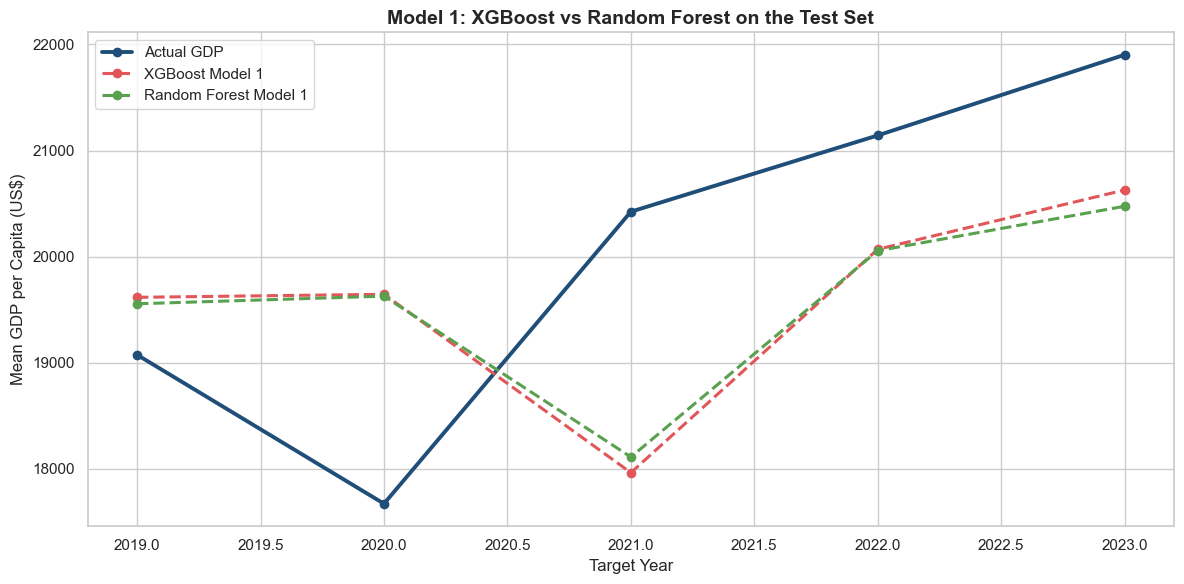

In [9]:
# Cell 9 - Plot Model 1 RF vs XGB

plot_family_compare(
    model_1_family_compare,
    "Model 1: XGBoost vs Random Forest on the Test Set"
)

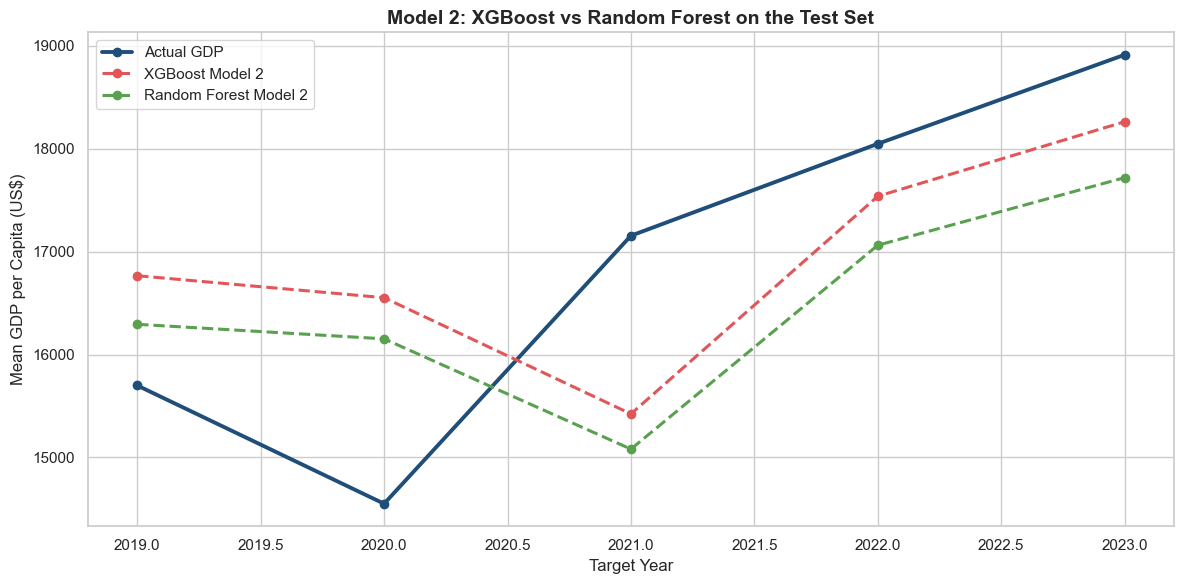

In [10]:
# Cell 10 - Plot Model 2 RF vs XGB

plot_family_compare(
    model_2_family_compare,
    "Model 2: XGBoost vs Random Forest on the Test Set"
)

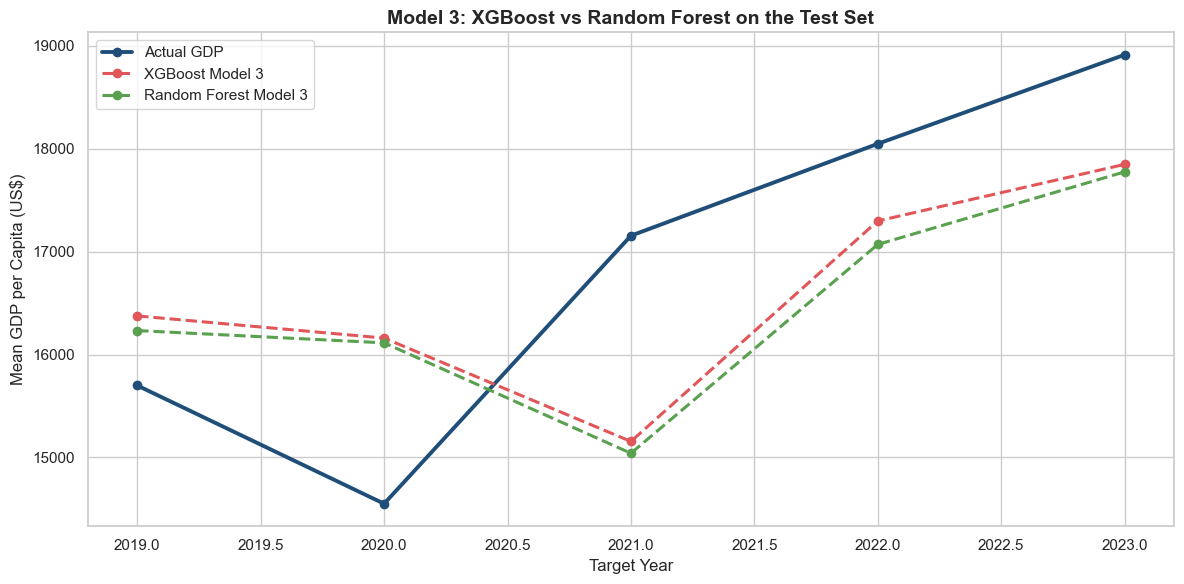

In [11]:
# Cell 11 - Plot Model 3 RF vs XGB

plot_family_compare(
    model_3_family_compare,
    "Model 3: XGBoost vs Random Forest on the Test Set"
)

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_DIR = BASE_DIR / "Data" / "Cleaned"

PANEL_PATH = DATA_DIR / "panel_with_event_dummies_and_extra_drivers.csv"

TRAIN_CONTEXT_YEARS = 5
plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
panel_df = pd.read_csv(PANEL_PATH)
panel_df["year"] = pd.to_numeric(panel_df["year"], errors="coerce").astype("Int64")
panel_df["gdp_per_capita_usd"] = pd.to_numeric(panel_df["gdp_per_capita_usd"], errors="coerce")

def load_family_predictions(model_number: int, family: str) -> pd.DataFrame:
    if family == "xgb":
        path = DATA_DIR / f"gdp_xgboost_model_{model_number}_test_predictions.csv"
        family_label = "XGBoost"
    elif family == "rf":
        path = DATA_DIR / f"gdp_random_forest_model_{model_number}_test_predictions.csv"
        family_label = "Random Forest"
    else:
        raise ValueError("family must be 'xgb' or 'rf'")

    df = pd.read_csv(path)

    keep_cols = [
        "country_code",
        "country_name",
        "wb_region",
        "feature_year",
        "target_year",
        "actual_gdp_next_year",
        "predicted_gdp_next_year",
    ]
    out = df[keep_cols].copy()
    out["feature_year"] = pd.to_numeric(out["feature_year"], errors="coerce").astype(int)
    out["target_year"] = pd.to_numeric(out["target_year"], errors="coerce").astype(int)
    out["actual_gdp_next_year"] = pd.to_numeric(out["actual_gdp_next_year"], errors="coerce")
    out["predicted_gdp_next_year"] = pd.to_numeric(out["predicted_gdp_next_year"], errors="coerce")
    out["family_label"] = family_label
    return out

def build_family_compare(model_number: int, train_context_years: int = 5) -> pd.DataFrame:
    xgb_df = load_family_predictions(model_number, "xgb")
    rf_df = load_family_predictions(model_number, "rf")

    join_cols = ["country_code", "feature_year", "target_year"]

    common_df = (
        xgb_df[join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]]
        .rename(columns={"predicted_gdp_next_year": "pred_xgb"})
        .merge(
            rf_df[join_cols + ["predicted_gdp_next_year"]].rename(
                columns={"predicted_gdp_next_year": "pred_rf"}
            ),
            on=join_cols,
            how="inner",
        )
    )

    common_country_codes = sorted(common_df["country_code"].dropna().unique().tolist())
    test_years = sorted(common_df["target_year"].dropna().unique().tolist())
    first_test_year = min(test_years)
    last_test_year = max(test_years)

    train_year_start = first_test_year - train_context_years
    train_context_df = (
        panel_df[
            panel_df["country_code"].isin(common_country_codes)
            & panel_df["year"].between(train_year_start, first_test_year - 1)
            & panel_df["gdp_per_capita_usd"].notna()
        ]
        .groupby("year", as_index=False)["gdp_per_capita_usd"]
        .mean()
        .rename(columns={"year": "plot_year", "gdp_per_capita_usd": "actual_gdp"})
    )
    train_context_df["pred_xgb"] = np.nan
    train_context_df["pred_rf"] = np.nan
    train_context_df["segment"] = "Train"

    test_summary_df = (
        common_df.groupby("target_year", as_index=False)[
            ["actual_gdp_next_year", "pred_xgb", "pred_rf"]
        ]
        .mean()
        .rename(
            columns={
                "target_year": "plot_year",
                "actual_gdp_next_year": "actual_gdp",
            }
        )
    )
    test_summary_df["segment"] = "Test"

    compare_df = pd.concat([train_context_df, test_summary_df], ignore_index=True)
    compare_df = compare_df.sort_values("plot_year").reset_index(drop=True)

    compare_df.attrs["first_test_year"] = first_test_year
    compare_df.attrs["last_test_year"] = last_test_year
    compare_df.attrs["train_year_start"] = train_year_start
    compare_df.attrs["train_context_years"] = train_context_years
    compare_df.attrs["model_number"] = model_number

    return compare_df

model_1_family_compare = build_family_compare(1, train_context_years=TRAIN_CONTEXT_YEARS)
model_2_family_compare = build_family_compare(2, train_context_years=TRAIN_CONTEXT_YEARS)
model_3_family_compare = build_family_compare(3, train_context_years=TRAIN_CONTEXT_YEARS)

display(model_3_family_compare)

,plot_year,actual_gdp,pred_xgb,pred_rf,segment
0,2014,"15,810.1898",NaN,NaN,Train
1,2015,"13,943.9234",NaN,NaN,Train
2,2016,"13,905.6090",NaN,NaN,Train
3,2017,"14,831.6327",NaN,NaN,Train
4,2018,"15,838.5790",NaN,NaN,Train
5,2019,"15,698.9605","16,375.2727","16,232.8993",Test
6,2020,"14,549.3612","16,159.8303","16,113.4938",Test
7,2021,"17,155.0981","15,154.9540","15,039.9489",Test
8,2022,"18,048.6179","17,298.4945","17,070.2421",Test
9,2023,"18,914.0876","17,848.6621","17,775.7104",Test


In [14]:
def plot_family_compare(compare_df: pd.DataFrame, title: str):
    first_test_year = compare_df.attrs["first_test_year"]
    last_test_year = compare_df.attrs["last_test_year"]
    train_year_start = compare_df.attrs["train_year_start"]

    years = compare_df["plot_year"].astype(int).tolist()

    fig, ax = plt.subplots(figsize=(14, 7))

    # Train/Test background
    ax.axvspan(train_year_start - 0.5, first_test_year - 0.5, color="#E2E8F0", alpha=0.40)
    ax.axvspan(first_test_year - 0.5, last_test_year + 0.5, color="#FEF3C7", alpha=0.22)

    # Actual full path: train + test
    ax.plot(
        compare_df["plot_year"],
        compare_df["actual_gdp"],
        marker="o",
        linewidth=2.8,
        color="#1D4E89",
        label="Actual GDP (Train + Test)"
    )

    # Predictions only on test
    ax.plot(
        compare_df["plot_year"],
        compare_df["pred_xgb"],
        marker="o",
        linestyle="--",
        linewidth=2.5,
        color="#E05A5A",
        label="XGBoost Prediction (Test)"
    )

    ax.plot(
        compare_df["plot_year"],
        compare_df["pred_rf"],
        marker="o",
        linestyle="--",
        linewidth=2.5,
        color="#72A95A",
        label="Random Forest Prediction (Test)"
    )

    # Train/Test split line
    ax.axvline(first_test_year - 0.5, color="#444444", linestyle=":", linewidth=1.8)

    # Labels for train/test areas
    y_top = np.nanmax([
        compare_df["actual_gdp"].max(),
        compare_df["pred_xgb"].max(),
        compare_df["pred_rf"].max(),
    ])

    ax.text(
        train_year_start,
        y_top * 1.01,
        "Train context",
        fontsize=11,
        fontweight="bold",
        color="#334155"
    )
    ax.text(
        first_test_year,
        y_top * 1.01,
        "Test period",
        fontsize=11,
        fontweight="bold",
        color="#92400E"
    )

    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("Mean GDP per Capita (US$)", fontsize=13)

    # Fix trục năm không còn số thập phân
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=0)

    ax.legend(fontsize=11, frameon=True)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

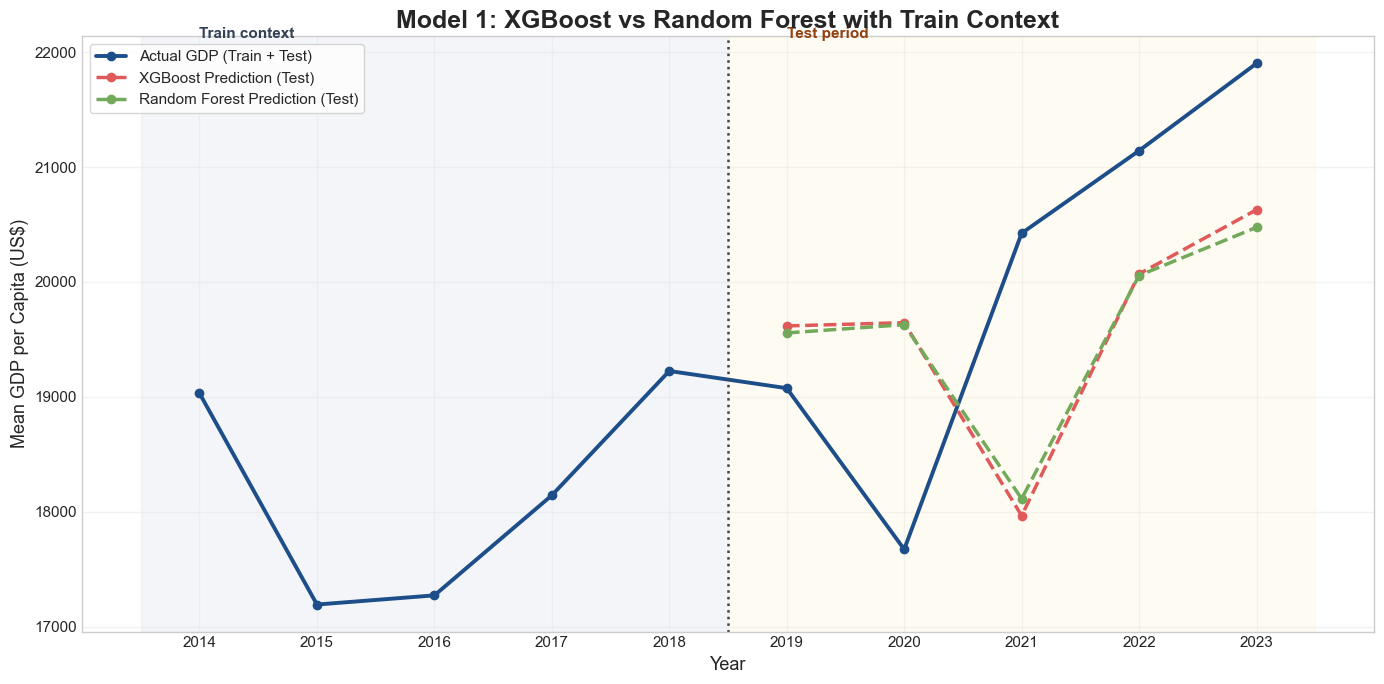

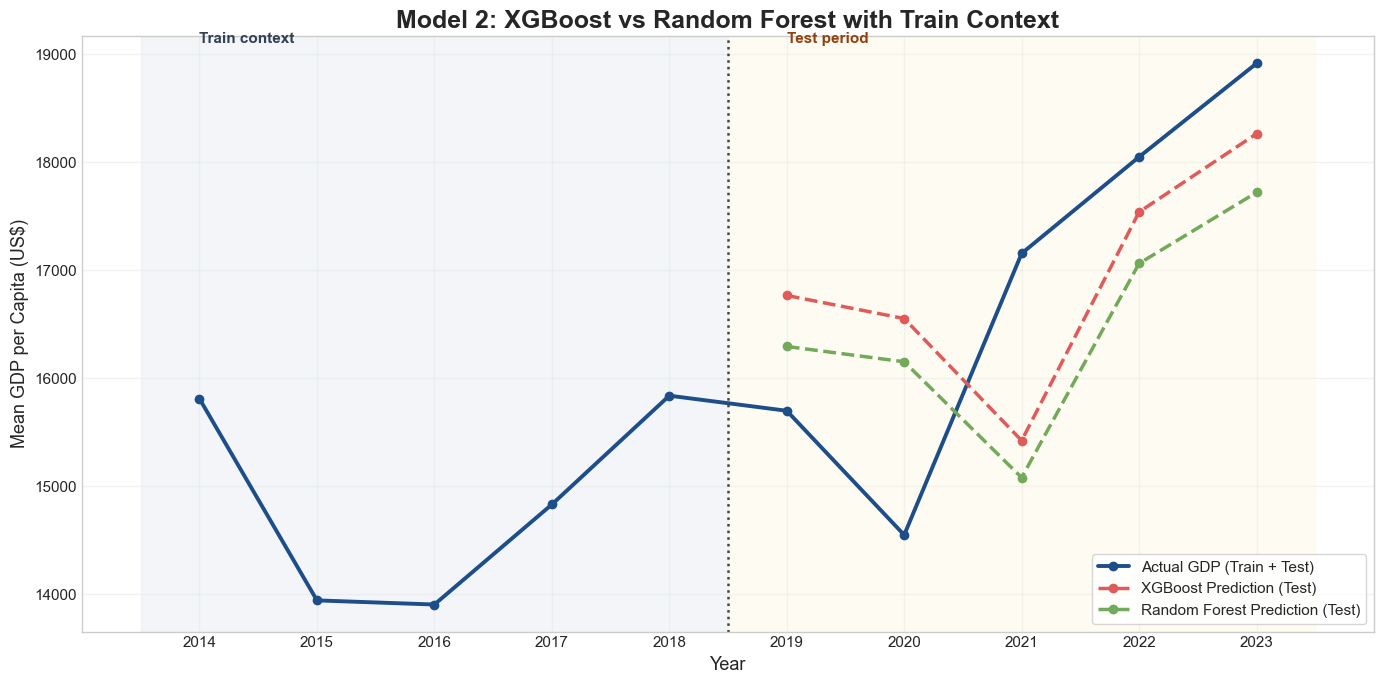

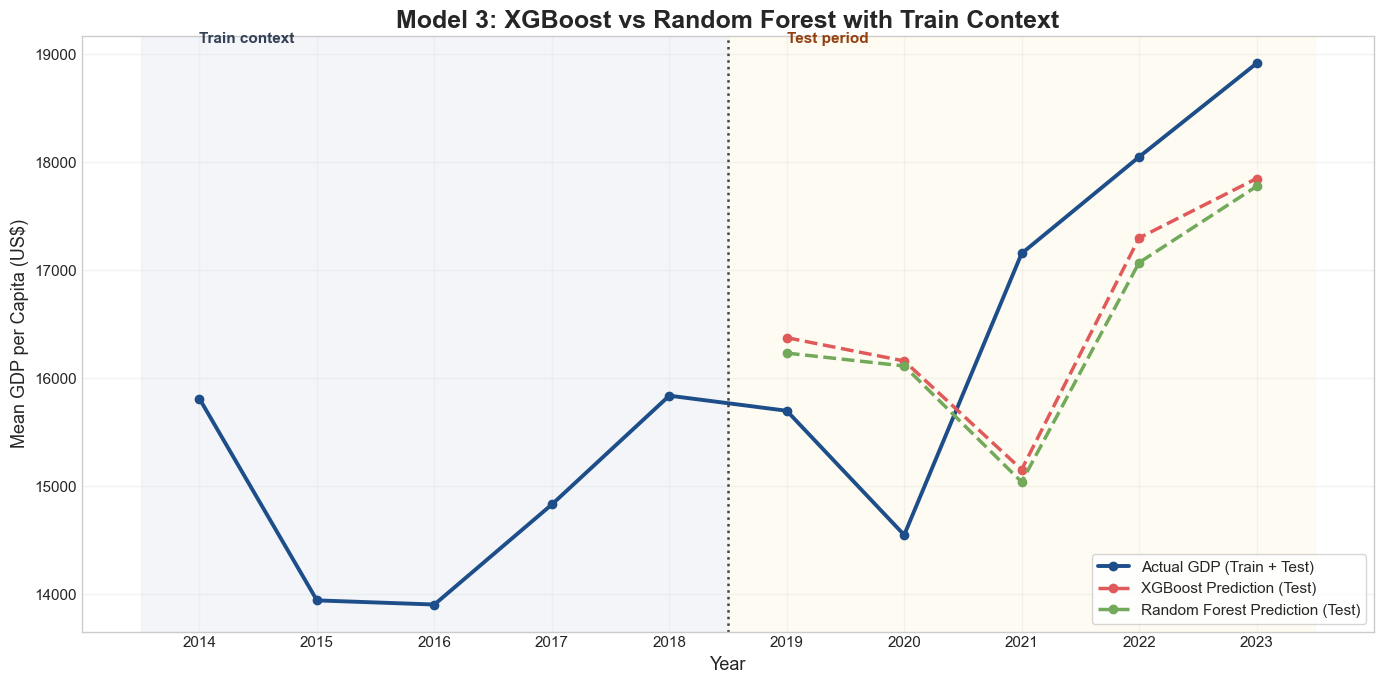

In [15]:
plot_family_compare(
    model_1_family_compare,
    "Model 1: XGBoost vs Random Forest with Train Context"
)

plot_family_compare(
    model_2_family_compare,
    "Model 2: XGBoost vs Random Forest with Train Context"
)

plot_family_compare(
    model_3_family_compare,
    "Model 3: XGBoost vs Random Forest with Train Context"
)

In [28]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"

TRAIN_END_YEAR = 2017
VALID_START_YEAR = 2016
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

TRAIN_DISPLAY_START_YEAR = 2000

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "seed": 42,
}

RF_CANDIDATE_PARAMS = [
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 14, "min_samples_leaf": 2, "max_features": 0.8},
]

In [21]:
def sanitize_feature_names(columns):
    out = []
    for col in columns:
        safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_")
        out.append(safe)
    return out


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def get_model_setup(model_number: int):
    if model_number == 1:
        model_cols = [
            "country_name", "country_code", "wb_region", "year",
            "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years",
            "target_log_gdp_next_year",
        ]
        numeric_cols = [
            "year", "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years", "target_log_gdp_next_year",
        ]
        feature_cols = [
            "log_gdp_per_capita",
            "log_population_total",
            "life_expectancy_years",
        ]
        use_dummies = False

    elif model_number == 2:
        model_cols = [
            "country_name", "country_code", "wb_region", "year",
            "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean", "unemployment_pct_clean", "internet_users_pct_clean",
            "target_log_gdp_next_year",
        ]
        numeric_cols = [
            "year", "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean", "unemployment_pct_clean", "internet_users_pct_clean",
            "target_log_gdp_next_year",
        ]
        feature_cols = [
            "log_gdp_per_capita",
            "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean",
            "unemployment_pct_clean",
            "internet_users_pct_clean",
        ]
        use_dummies = False

    elif model_number == 3:
        model_cols = [
            "country_name", "country_code", "wb_region", "year",
            "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean", "unemployment_pct_clean", "internet_users_pct_clean",
            "target_log_gdp_next_year",
            "asian_financial_crisis_9798", "global_financial_crisis_0809",
        ]
        numeric_cols = [
            "year", "gdp_per_capita_usd", "log_gdp_per_capita",
            "population_total", "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean", "unemployment_pct_clean", "internet_users_pct_clean",
            "target_log_gdp_next_year",
            "asian_financial_crisis_9798", "global_financial_crisis_0809",
        ]
        feature_cols = [
            "log_gdp_per_capita",
            "log_population_total",
            "life_expectancy_years",
            "inflation_pct_clean",
            "unemployment_pct_clean",
            "internet_users_pct_clean",
            "asian_financial_crisis_9798",
            "global_financial_crisis_0809",
            "year_trend",
            "wb_region",
        ]
        use_dummies = True

    else:
        raise ValueError("model_number must be 1, 2, or 3")

    return model_cols, numeric_cols, feature_cols, use_dummies


def prepare_model_data(model_number: int):
    model_cols, numeric_cols, feature_cols, use_dummies = get_model_setup(model_number)

    panel_df = pd.read_csv(DATA_PATH, usecols=model_cols).copy()

    for col in numeric_cols:
        panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

    model_df = panel_df.dropna().copy()
    model_df["year"] = model_df["year"].astype(int)
    model_df["country_name"] = model_df["country_name"].astype(str)
    model_df["country_code"] = model_df["country_code"].astype(str)
    model_df["wb_region"] = model_df["wb_region"].astype(str)

    if model_number == 3:
        model_df["year_trend"] = model_df["year"] - model_df["year"].min()

    target_col = "target_log_gdp_next_year"

    if use_dummies:
        X_all = pd.get_dummies(
            model_df[feature_cols],
            columns=["wb_region"],
            drop_first=False
        )
        X_all.columns = sanitize_feature_names(X_all.columns)
    else:
        X_all = model_df[feature_cols].copy()

    return model_df, X_all, target_col


def build_split_frames(model_df, X_all, target_col):
    train_full_mask = model_df["year"] <= TRAIN_END_YEAR
    train_core_mask = model_df["year"] < VALID_START_YEAR
    valid_mask = (model_df["year"] >= VALID_START_YEAR) & (model_df["year"] <= TRAIN_END_YEAR)
    test_mask = (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)

    split = {
        "train_full_df": model_df.loc[train_full_mask].copy(),
        "train_core_df": model_df.loc[train_core_mask].copy(),
        "valid_df": model_df.loc[valid_mask].copy(),
        "test_df": model_df.loc[test_mask].copy(),
        "X_train_full": X_all.loc[train_full_mask].copy(),
        "y_train_full": model_df.loc[train_full_mask, target_col].copy(),
        "X_train_core": X_all.loc[train_core_mask].copy(),
        "y_train_core": model_df.loc[train_core_mask, target_col].copy(),
        "X_valid": X_all.loc[valid_mask].copy(),
        "y_valid": model_df.loc[valid_mask, target_col].copy(),
        "X_test": X_all.loc[test_mask].copy(),
        "y_test": model_df.loc[test_mask, target_col].copy(),
    }
    return split


def build_prediction_df(base_df, pred_log_values, family_label):
    out = base_df[
        ["country_name", "country_code", "wb_region", "year", "gdp_per_capita_usd", "target_log_gdp_next_year"]
    ].copy()

    out["predicted_log_gdp_next_year"] = pred_log_values
    out["actual_log_gdp_next_year"] = out["target_log_gdp_next_year"]
    out["predicted_gdp_next_year"] = np.exp(out["predicted_log_gdp_next_year"])
    out["actual_gdp_next_year"] = np.exp(out["actual_log_gdp_next_year"])
    out["feature_year"] = out["year"]
    out["target_year"] = out["year"] + 1
    out["family"] = family_label

    return out


def fit_xgb_model(model_number: int):
    model_df, X_all, target_col = prepare_model_data(model_number)
    split = build_split_frames(model_df, X_all, target_col)

    dtrain_core = xgb.DMatrix(split["X_train_core"], label=split["y_train_core"])
    dvalid = xgb.DMatrix(split["X_valid"], label=split["y_valid"])
    dtrain_full = xgb.DMatrix(split["X_train_full"], label=split["y_train_full"])
    dtest = xgb.DMatrix(split["X_test"], label=split["y_test"])

    early_stop_booster = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain_core,
        num_boost_round=500,
        evals=[(dtrain_core, "train_core"), (dvalid, "valid")],
        early_stopping_rounds=30,
        verbose_eval=False,
    )

    best_rounds = early_stop_booster.best_iteration + 1

    final_booster = xgb.train(
        params=XGB_PARAMS,
        dtrain=dtrain_full,
        num_boost_round=best_rounds,
        evals=[(dtrain_full, "train_full")],
        verbose_eval=False,
    )

    train_pred_log = final_booster.predict(dtrain_full)
    test_pred_log = final_booster.predict(dtest)

    train_pred_df = build_prediction_df(split["train_full_df"], train_pred_log, "XGBoost")
    test_pred_df = build_prediction_df(split["test_df"], test_pred_log, "XGBoost")

    return train_pred_df, test_pred_df


def fit_rf_model(model_number: int):
    model_df, X_all, target_col = prepare_model_data(model_number)
    split = build_split_frames(model_df, X_all, target_col)

    search_rows = []
    best_model = None
    best_key = None
    best_params = None

    for params in RF_CANDIDATE_PARAMS:
        model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params,
        )
        model.fit(split["X_train_core"], split["y_train_core"])

        valid_pred_log = model.predict(split["X_valid"])
        valid_pred_level = np.exp(valid_pred_log)
        valid_actual_level = np.exp(split["y_valid"])

        metrics = regression_metrics(valid_actual_level, valid_pred_level)
        key = (metrics["RMSE"], metrics["MAPE_pct"], metrics["MAE"])

        search_rows.append({**params, **metrics})

        if best_key is None or key < best_key:
            best_key = key
            best_params = params

    final_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_params,
    )
    final_model.fit(split["X_train_full"], split["y_train_full"])

    train_pred_log = final_model.predict(split["X_train_full"])
    test_pred_log = final_model.predict(split["X_test"])

    train_pred_df = build_prediction_df(split["train_full_df"], train_pred_log, "Random Forest")
    test_pred_df = build_prediction_df(split["test_df"], test_pred_log, "Random Forest")

    return train_pred_df, test_pred_df

In [29]:
def build_family_compare_with_train_predictions(model_number: int, train_display_start_year: int = 2000):
    xgb_train_df, xgb_test_df = fit_xgb_model(model_number)
    rf_train_df, rf_test_df = fit_rf_model(model_number)

    join_cols = ["country_code", "feature_year", "target_year"]

    train_common_df = (
        xgb_train_df[join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]]
        .rename(columns={"predicted_gdp_next_year": "xgb_pred"})
        .merge(
            rf_train_df[join_cols + ["predicted_gdp_next_year"]]
            .rename(columns={"predicted_gdp_next_year": "rf_pred"}),
            on=join_cols,
            how="inner",
        )
    )

    test_common_df = (
        xgb_test_df[join_cols + ["actual_gdp_next_year", "predicted_gdp_next_year"]]
        .rename(columns={"predicted_gdp_next_year": "xgb_pred"})
        .merge(
            rf_test_df[join_cols + ["predicted_gdp_next_year"]]
            .rename(columns={"predicted_gdp_next_year": "rf_pred"}),
            on=join_cols,
            how="inner",
        )
    )

    train_yearly_df = (
        train_common_df.groupby("target_year", as_index=False)[["actual_gdp_next_year", "xgb_pred", "rf_pred"]]
        .mean()
        .rename(
            columns={
                "target_year": "plot_year",
                "actual_gdp_next_year": "actual_gdp",
            }
        )
    )
    train_yearly_df["segment"] = "Train"

    test_yearly_df = (
        test_common_df.groupby("target_year", as_index=False)[["actual_gdp_next_year", "xgb_pred", "rf_pred"]]
        .mean()
        .rename(
            columns={
                "target_year": "plot_year",
                "actual_gdp_next_year": "actual_gdp",
            }
        )
    )
    test_yearly_df["segment"] = "Test"

    train_yearly_df = train_yearly_df[train_yearly_df["plot_year"] >= train_display_start_year].copy()

    compare_df = pd.concat([train_yearly_df, test_yearly_df], ignore_index=True)
    compare_df = compare_df.sort_values("plot_year").reset_index(drop=True)

    compare_df.attrs["first_test_year"] = int(test_yearly_df["plot_year"].min())
    compare_df.attrs["last_test_year"] = int(test_yearly_df["plot_year"].max())
    compare_df.attrs["train_display_start_year"] = train_display_start_year
    compare_df.attrs["model_number"] = model_number

    return compare_df


model_1_family_compare = build_family_compare_with_train_predictions(1, train_display_start_year=2000)
model_2_family_compare = build_family_compare_with_train_predictions(2, train_display_start_year=2000)
model_3_family_compare = build_family_compare_with_train_predictions(3, train_display_start_year=2000)

display(model_1_family_compare)
display(model_2_family_compare)
display(model_3_family_compare)

,plot_year,actual_gdp,xgb_pred,rf_pred,segment
0,2000,"8,211.7827","8,568.5283","8,405.2147",Train
1,2001,"8,171.5160","8,557.9600","8,440.4063",Train
2,2002,"8,695.5577","8,656.3945","8,656.4399",Train
3,2003,"10,260.4725","9,443.2520","9,695.2385",Train
4,2004,"11,678.4614","11,065.9434","11,182.0212",Train
5,2005,"12,661.1323","12,452.3936","12,479.3256",Train
6,2006,"13,844.2913","13,383.7803","13,512.0604",Train
7,2007,"16,155.8032","14,994.4824","15,268.6318",Train
8,2008,"17,602.0737","16,414.7266","16,843.1061",Train
9,2009,"15,369.6030","17,332.8086","16,583.9666",Train


,plot_year,actual_gdp,xgb_pred,rf_pred,segment
0,2000,"7,145.4809","7,315.4487","7,217.3700",Train
1,2001,"7,014.7569","7,417.5889","7,217.6004",Train
2,2002,"7,216.1784","7,157.4312","7,175.0597",Train
3,2003,"8,244.8198","7,569.0503","7,850.1898",Train
4,2004,"9,622.9956","8,964.9541","9,223.1661",Train
5,2005,"10,502.9690","10,211.6240","10,306.0890",Train
6,2006,"11,298.6274","10,954.9160","11,114.1605",Train
7,2007,"12,839.7884","11,883.6309","12,333.0006",Train
8,2008,"13,999.9457","13,081.6865","13,500.2300",Train
9,2009,"12,571.7681","13,863.0371","13,456.5234",Train


,plot_year,actual_gdp,xgb_pred,rf_pred,segment
0,2000,"7,145.4809","7,097.3789","7,180.2029",Train
1,2001,"7,014.7569","7,278.9819","7,192.7094",Train
2,2002,"7,216.1784","7,101.2690","7,189.9813",Train
3,2003,"8,244.8198","7,730.3169","7,931.8528",Train
4,2004,"9,622.9956","9,048.6973","9,306.5536",Train
5,2005,"10,502.9690","10,302.7012","10,399.8049",Train
6,2006,"11,298.6274","11,084.7646","11,216.4555",Train
7,2007,"12,839.7884","12,092.1426","12,447.7465",Train
8,2008,"13,999.9457","13,390.2295","13,672.0472",Train
9,2009,"12,571.7681","13,138.5537","13,336.2810",Train


In [30]:
def plot_family_compare(compare_df: pd.DataFrame, title: str):
    first_test_year = compare_df.attrs["first_test_year"]
    last_test_year = compare_df.attrs["last_test_year"]
    train_display_start_year = compare_df.attrs["train_display_start_year"]

    train_df = compare_df[compare_df["segment"] == "Train"].copy()
    test_df = compare_df[compare_df["segment"] == "Test"].copy()

    all_years = compare_df["plot_year"].astype(int).tolist()

    fig, ax = plt.subplots(figsize=(14, 7))

    # Background shading
    ax.axvspan(train_display_start_year - 0.5, first_test_year - 0.5, color="#E8EEF9", alpha=0.55)
    ax.axvspan(first_test_year - 0.5, last_test_year + 0.5, color="#FFF4DB", alpha=0.45)

    # Actual full line
    ax.plot(
        compare_df["plot_year"],
        compare_df["actual_gdp"],
        marker="o",
        linewidth=2.8,
        color="#1D4E89",
        label="Actual GDP (Train + Test)",
    )

    # XGBoost train
    ax.plot(
        train_df["plot_year"],
        train_df["xgb_pred"],
        marker="o",
        linewidth=2.2,
        linestyle="-",
        alpha=0.75,
        color="#E06666",
        label="XGBoost Prediction (Train)",
    )

    # XGBoost test
    ax.plot(
        test_df["plot_year"],
        test_df["xgb_pred"],
        marker="o",
        linewidth=2.5,
        linestyle="--",
        color="#D9534F",
        label="XGBoost Prediction (Test)",
    )

    # RF train
    ax.plot(
        train_df["plot_year"],
        train_df["rf_pred"],
        marker="o",
        linewidth=2.2,
        linestyle="-",
        alpha=0.75,
        color="#8CBF74",
        label="Random Forest Prediction (Train)",
    )

    # RF test
    ax.plot(
        test_df["plot_year"],
        test_df["rf_pred"],
        marker="o",
        linewidth=2.5,
        linestyle="--",
        color="#6AA84F",
        label="Random Forest Prediction (Test)",
    )

    # Split line
    ax.axvline(first_test_year - 0.5, color="#666666", linestyle=":", linewidth=1.8)

    y_top = np.nanmax([
        compare_df["actual_gdp"].max(),
        compare_df["xgb_pred"].max(),
        compare_df["rf_pred"].max(),
    ])

    ax.text(
        train_display_start_year + 0.2,
        y_top * 1.005,
        "Train period",
        fontsize=11,
        fontweight="bold",
        color="#334155"
    )
    ax.text(
        first_test_year + 0.05,
        y_top * 1.005,
        "Test period",
        fontsize=11,
        fontweight="bold",
        color="#B45309"
    )

    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("Mean GDP per Capita (US$)", fontsize=13)

    # Fix x-axis years: no decimals
    ax.set_xticks(all_years)
    ax.set_xticklabels([str(y) for y in all_years], rotation=0)

    ax.legend(fontsize=10.5, frameon=True, ncol=2)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

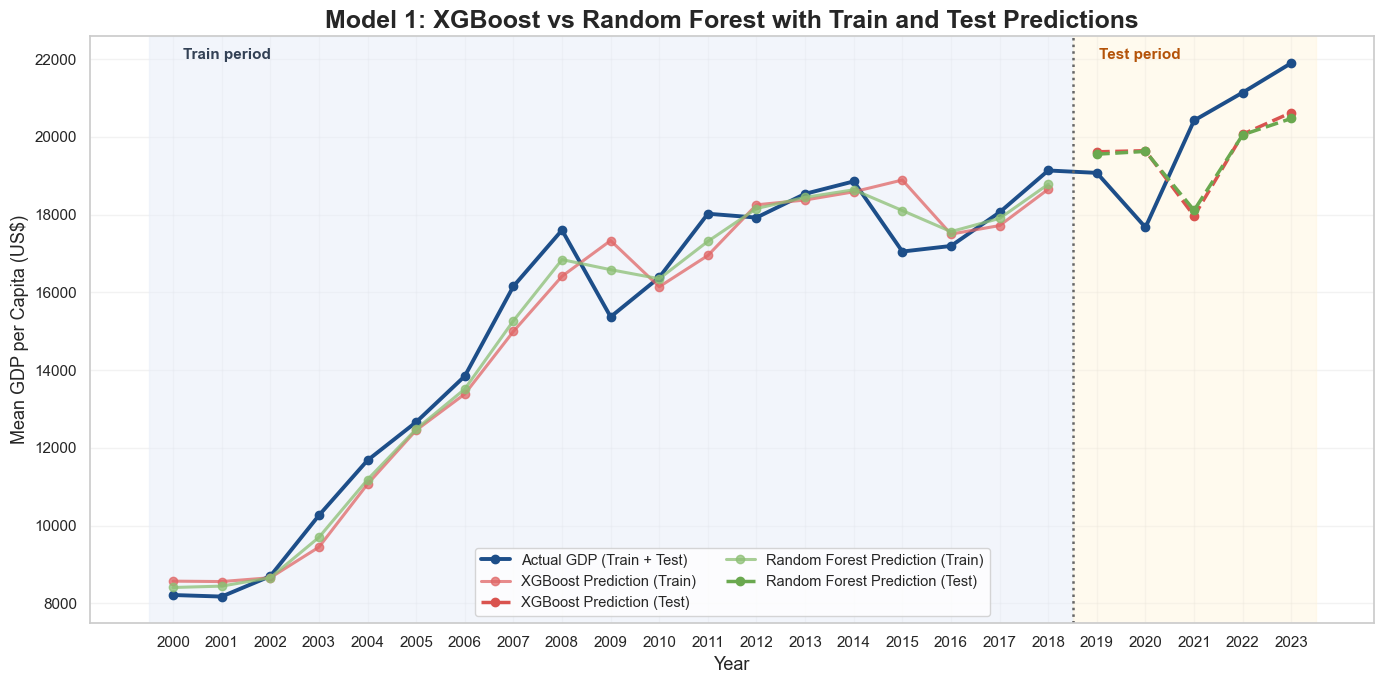

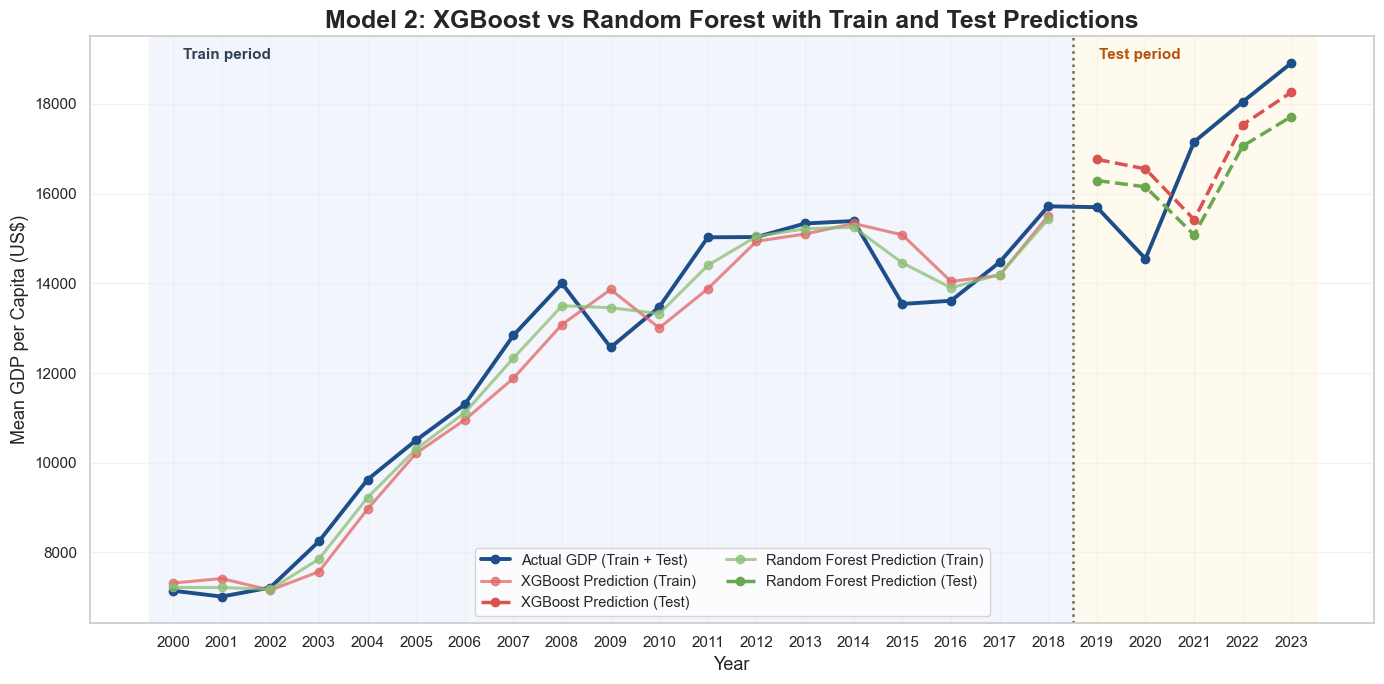

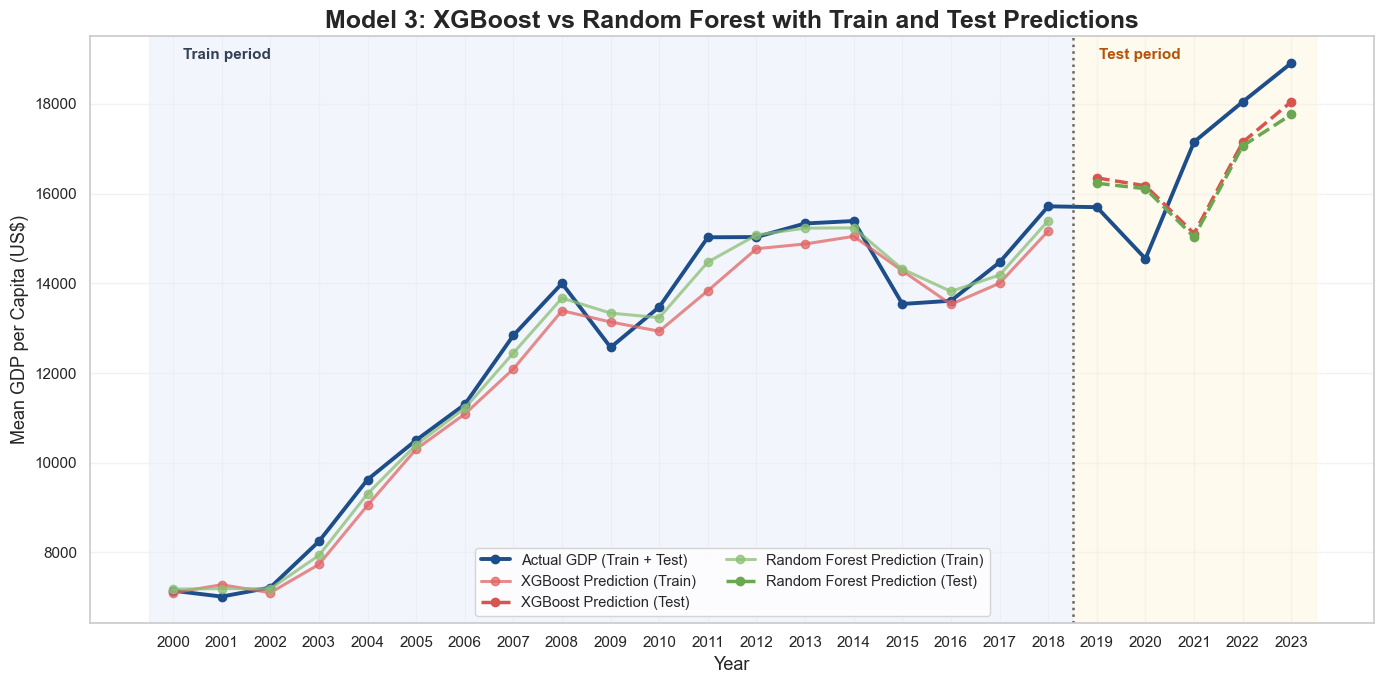

In [31]:
plot_family_compare(
    model_1_family_compare,
    "Model 1: XGBoost vs Random Forest with Train and Test Predictions"
)

plot_family_compare(
    model_2_family_compare,
    "Model 2: XGBoost vs Random Forest with Train and Test Predictions"
)

plot_family_compare(
    model_3_family_compare,
    "Model 3: XGBoost vs Random Forest with Train and Test Predictions"
)